#  Experiment 2: QCBM Basics

## Quantum Circuit Born Machines - Core Concepts

**Objective:** Understand how QCBM works and visualize the quantum circuit architecture.

**Topics Covered:**
- The Born Rule and probability sampling
- Hardware-efficient ansatz design
- Entanglement topologies: None, Linear, Circular, Full
- Parameter counting and circuit complexity

---

In [12]:
# Setup and imports
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

from src.models.qcbm import QCBM, create_qcbm, create_separable_qcbm, create_entangled_qcbm
from src.models.ansatz import HardwareEfficientAnsatz, draw_ansatz
from src.utils.visualization import set_style, plot_distribution
from src.utils.figure_saver import save_figure
from config import RANDOM_SEED

set_style()
np.random.seed(RANDOM_SEED)
print(" Setup complete!")
print(f" PennyLane version: {qml.__version__}")

 Setup complete!
 PennyLane version: 0.44.0


## 1. The Born Rule

A Quantum Circuit Born Machine (QCBM) uses the **Born Rule** to generate probabilities:

$$P(x) = |\langle x | \psi(\theta) \rangle|^2$$

Where:
- $|\psi(\theta)\rangle$ is the parameterized quantum state
- $|x\rangle$ is a computational basis state
- $\theta$ are the trainable parameters

This makes QCBMs **native probability samplers** - they don't need to normalize like classical models!

## 2. Hardware-Efficient Ansatz

Our ansatz consists of:
1. **Single-qubit rotations:** $R_Y(\theta)$ and $R_Z(\theta)$
2. **Entangling gates:** CNOT gates with configurable topology

In [13]:
# Create ansätze with different topologies
n_qubits = 4
n_layers = 2

topologies = ['none', 'linear', 'circular', 'full']

print(" Ansatz Configurations:")
print("=" * 50)

for topology in topologies:
    ansatz = HardwareEfficientAnsatz(
        n_qubits=n_qubits,
        n_layers=n_layers,
        topology=topology
    )
    print(f"\n Topology: {topology.upper()}")
    print(f"   Parameters: {ansatz.n_params}")
    print(f"   CNOT pairs: {len(ansatz.entanglement_pairs)}")
    if ansatz.entanglement_pairs:
        print(f"   Connections: {ansatz.entanglement_pairs}")

 Ansatz Configurations:

 Topology: NONE
   Parameters: 16
   CNOT pairs: 0

 Topology: LINEAR
   Parameters: 16
   CNOT pairs: 3
   Connections: [(0, 1), (1, 2), (2, 3)]

 Topology: CIRCULAR
   Parameters: 16
   CNOT pairs: 4
   Connections: [(0, 1), (1, 2), (2, 3), (3, 0)]

 Topology: FULL
   Parameters: 16
   CNOT pairs: 6
   Connections: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]


In [14]:
# Visualize the circuit structure for each topology
print("\n Circuit Diagrams:")
print("=" * 60)

for topology in topologies:
    print(f"\n--- {topology.upper()} TOPOLOGY ---")
    ansatz = HardwareEfficientAnsatz(
        n_qubits=n_qubits,
        n_layers=1,  # Just 1 layer for clarity
        topology=topology
    )
    draw_ansatz(ansatz)


 Circuit Diagrams:

--- NONE TOPOLOGY ---
0: ──RY(0.00)──RZ(0.00)─┤ ╭Probs
1: ──RY(0.00)──RZ(0.00)─┤ ├Probs
2: ──RY(0.00)──RZ(0.00)─┤ ├Probs
3: ──RY(0.00)──RZ(0.00)─┤ ╰Probs

--- LINEAR TOPOLOGY ---
0: ──RY(0.00)──RZ(0.00)─╭●───────┤ ╭Probs
1: ──RY(0.00)──RZ(0.00)─╰X─╭●────┤ ├Probs
2: ──RY(0.00)──RZ(0.00)────╰X─╭●─┤ ├Probs
3: ──RY(0.00)──RZ(0.00)───────╰X─┤ ╰Probs

--- CIRCULAR TOPOLOGY ---
0: ──RY(0.00)──RZ(0.00)─╭●───────╭X─┤ ╭Probs
1: ──RY(0.00)──RZ(0.00)─╰X─╭●────│──┤ ├Probs
2: ──RY(0.00)──RZ(0.00)────╰X─╭●─│──┤ ├Probs
3: ──RY(0.00)──RZ(0.00)───────╰X─╰●─┤ ╰Probs

--- FULL TOPOLOGY ---
0: ──RY(0.00)──RZ(0.00)─╭●─╭●─╭●──────────┤ ╭Probs
1: ──RY(0.00)──RZ(0.00)─╰X─│──│──╭●─╭●────┤ ├Probs
2: ──RY(0.00)──RZ(0.00)────╰X─│──╰X─│──╭●─┤ ├Probs
3: ──RY(0.00)──RZ(0.00)───────╰X────╰X─╰X─┤ ╰Probs


## 3. Create and Test a QCBM

In [15]:
# Create a QCBM with full entanglement
qcbm = QCBM(
    n_qubits=4,
    n_layers=3,
    topology='full'
)

print(qcbm)
print(f"\n Output space: {qcbm.n_states} states")
print(f" Trainable parameters: {qcbm.n_params}")

QCBM(n_qubits=4, n_layers=3, topology='full')

 Output space: 16 states
 Trainable parameters: 24


In [16]:
# Get initial random parameters
params = qcbm.get_initial_params(strategy='random', seed=42)
print(f" Parameters shape: {params.shape}")
print(f"   First 5 values: {params[:5]}")

 Parameters shape: (24,)
   First 5 values: [2.35330497 5.97351416 4.59925358 3.76148219 0.98029403]


In [17]:
# Get the output probability distribution
probs = qcbm.get_probabilities(params)

print(f"\n Output Distribution:")
print(f"   Shape: {probs.shape}")
print(f"   Sum: {probs.sum():.6f} (should be 1.0)")
print(f"   Min: {probs.min():.6f}")
print(f"   Max: {probs.max():.6f}")


 Output Distribution:
   Shape: (16,)
   Sum: 1.000000 (should be 1.0)
   Min: 0.003457
   Max: 0.188791


/tmp/ipykernel_166682/1341766939.py:11: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../src/utils/figure_saver.py:67: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  fig.savefig(filepath, dpi=dpi, format=format, bbox_inches=bbox,
/home/jacopo/Documenti/Trento/QuantumML/MusicProject/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp02_qcbm_output_distribution.png


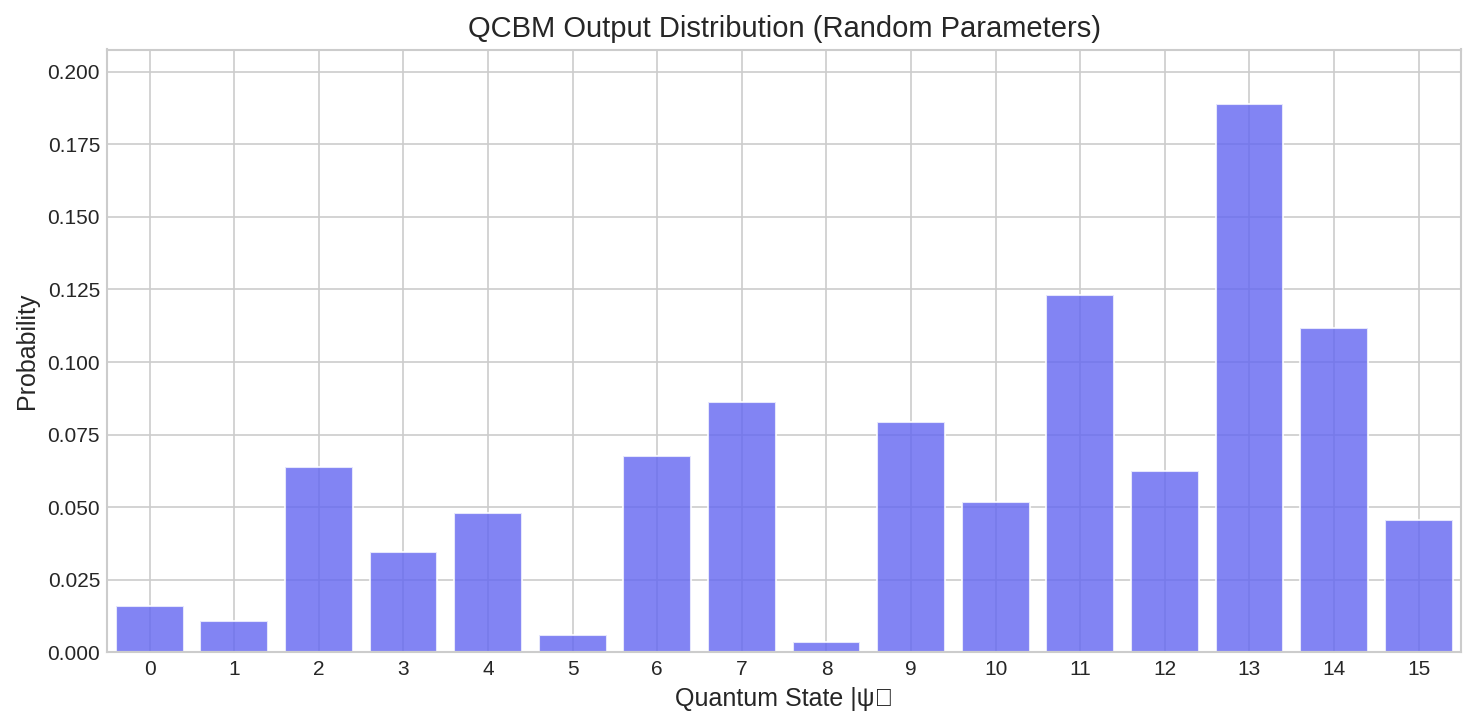

In [18]:
# Visualize the output distribution
fig, ax = plt.subplots(figsize=(10, 5))

plot_distribution(
    probs,
    title='QCBM Output Distribution (Random Parameters)',
    ax=ax,
    xlabel='Quantum State |ψ⟩'
)

plt.tight_layout()
save_figure(fig, 'qcbm_output_distribution', experiment='exp02')
plt.show()

## 4. Compare Topologies: Expressibility

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp02_topology_distributions.png


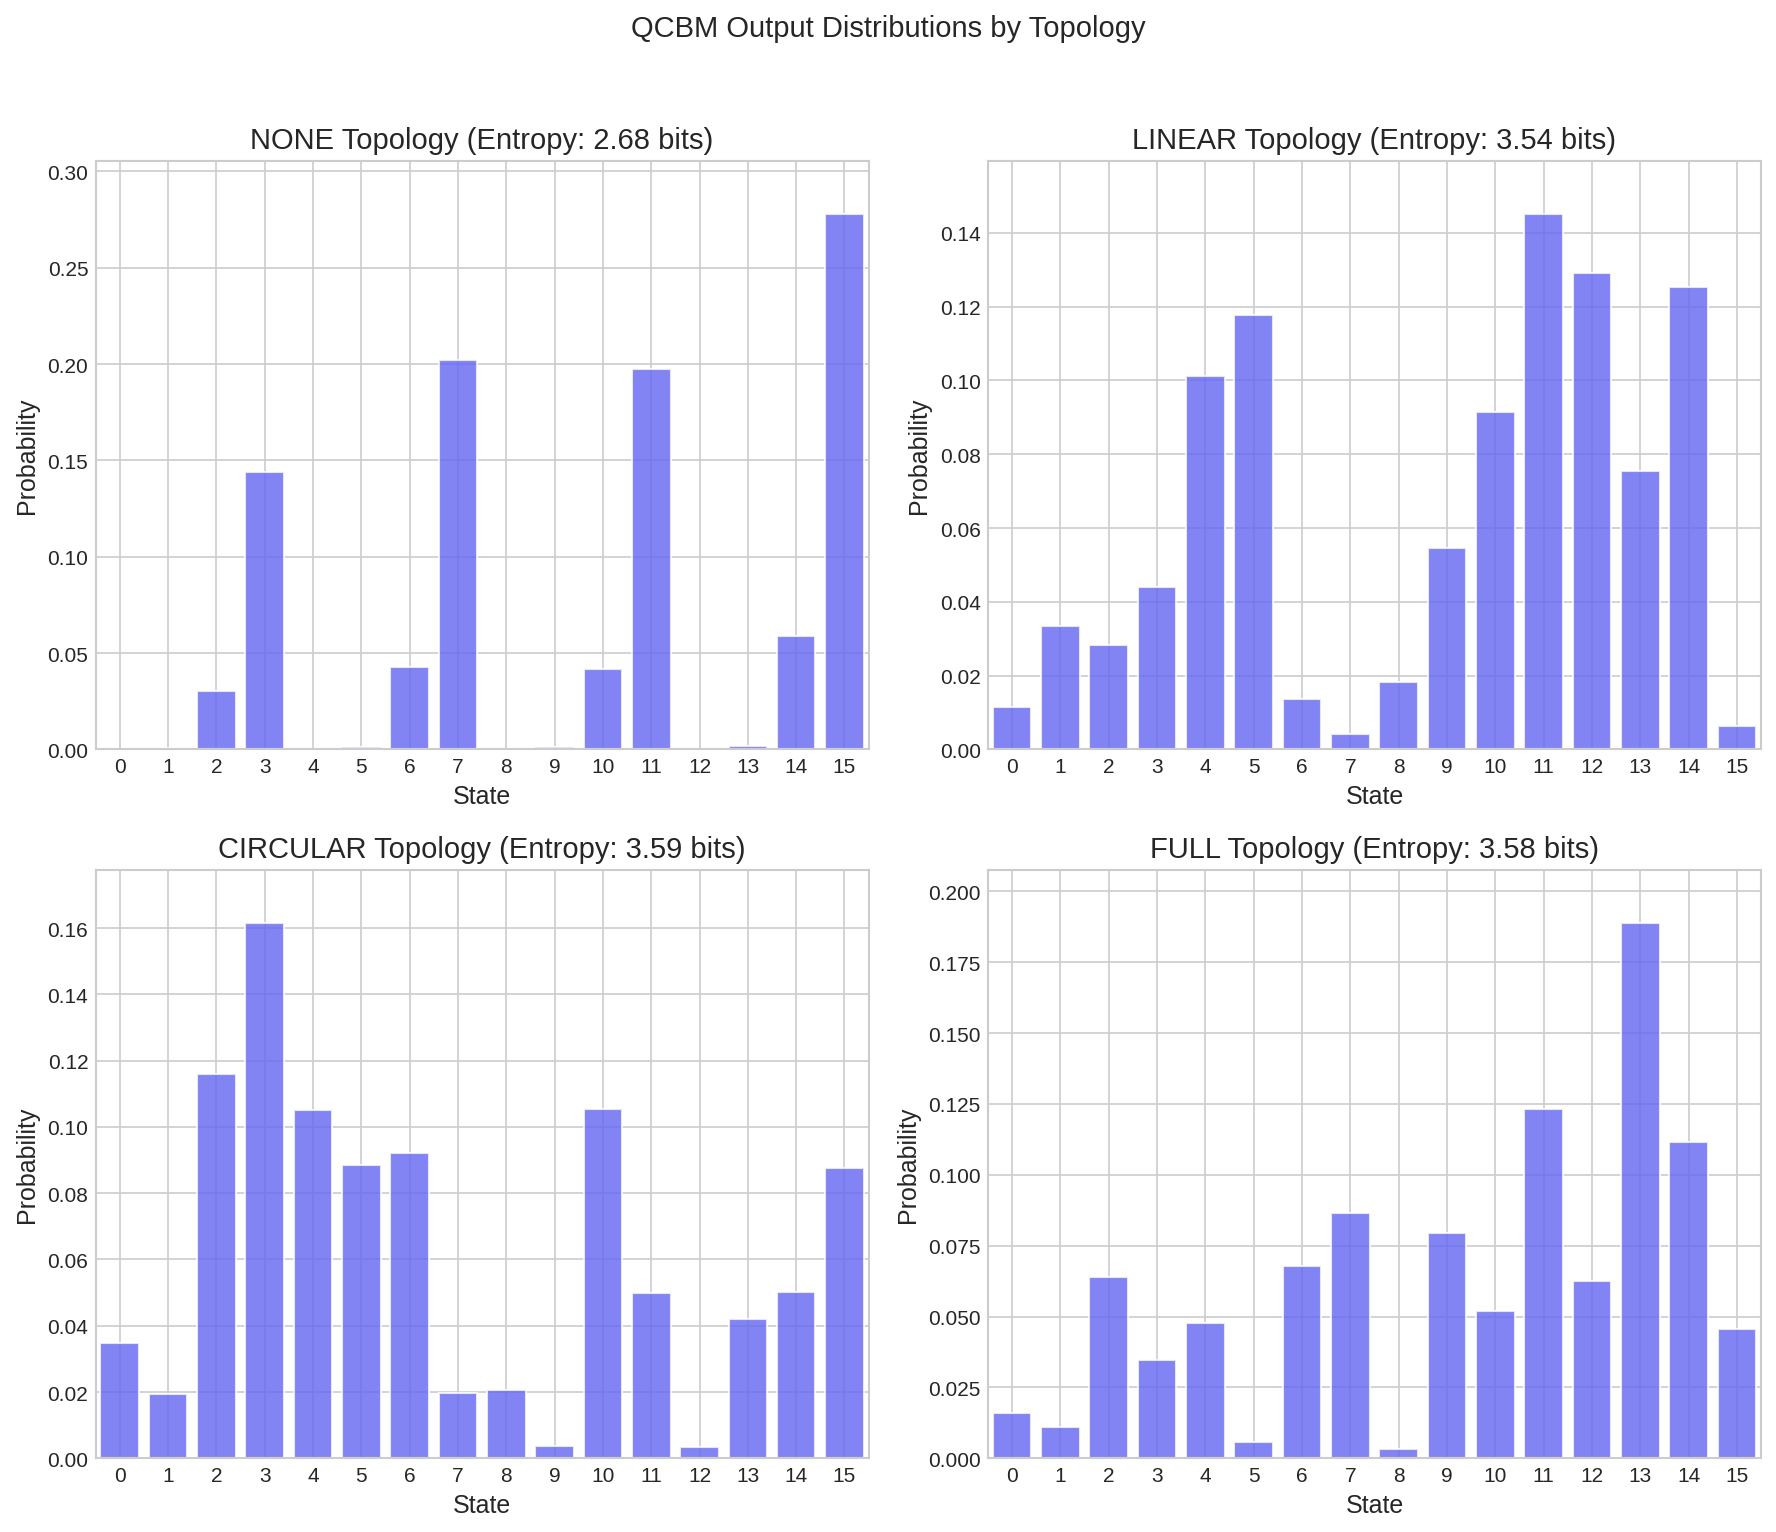

In [19]:
# Compare output distributions from different topologies
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, topology in enumerate(topologies):
    qcbm = QCBM(n_qubits=4, n_layers=3, topology=topology)
    params = qcbm.get_initial_params(seed=42)
    probs = qcbm.get_probabilities(params)
    
    # Calculate entropy as a measure of expressibility
    entropy = -np.sum(probs * np.log2(probs + 1e-10))
    
    plot_distribution(
        probs,
        title=f'{topology.upper()} Topology (Entropy: {entropy:.2f} bits)',
        ax=axes[idx]
    )

plt.suptitle('QCBM Output Distributions by Topology', fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, 'topology_distributions', experiment='exp02')
plt.show()

## 5. Sampling from QCBM

 Generated 1000 samples
   Sample values: [10 13  6 11 12  2 12  4  2 14 15 13  7  3 13 10  3 11  2 14]...
 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp02_sampling_comparison.png
 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp02_sampling_comparison.png


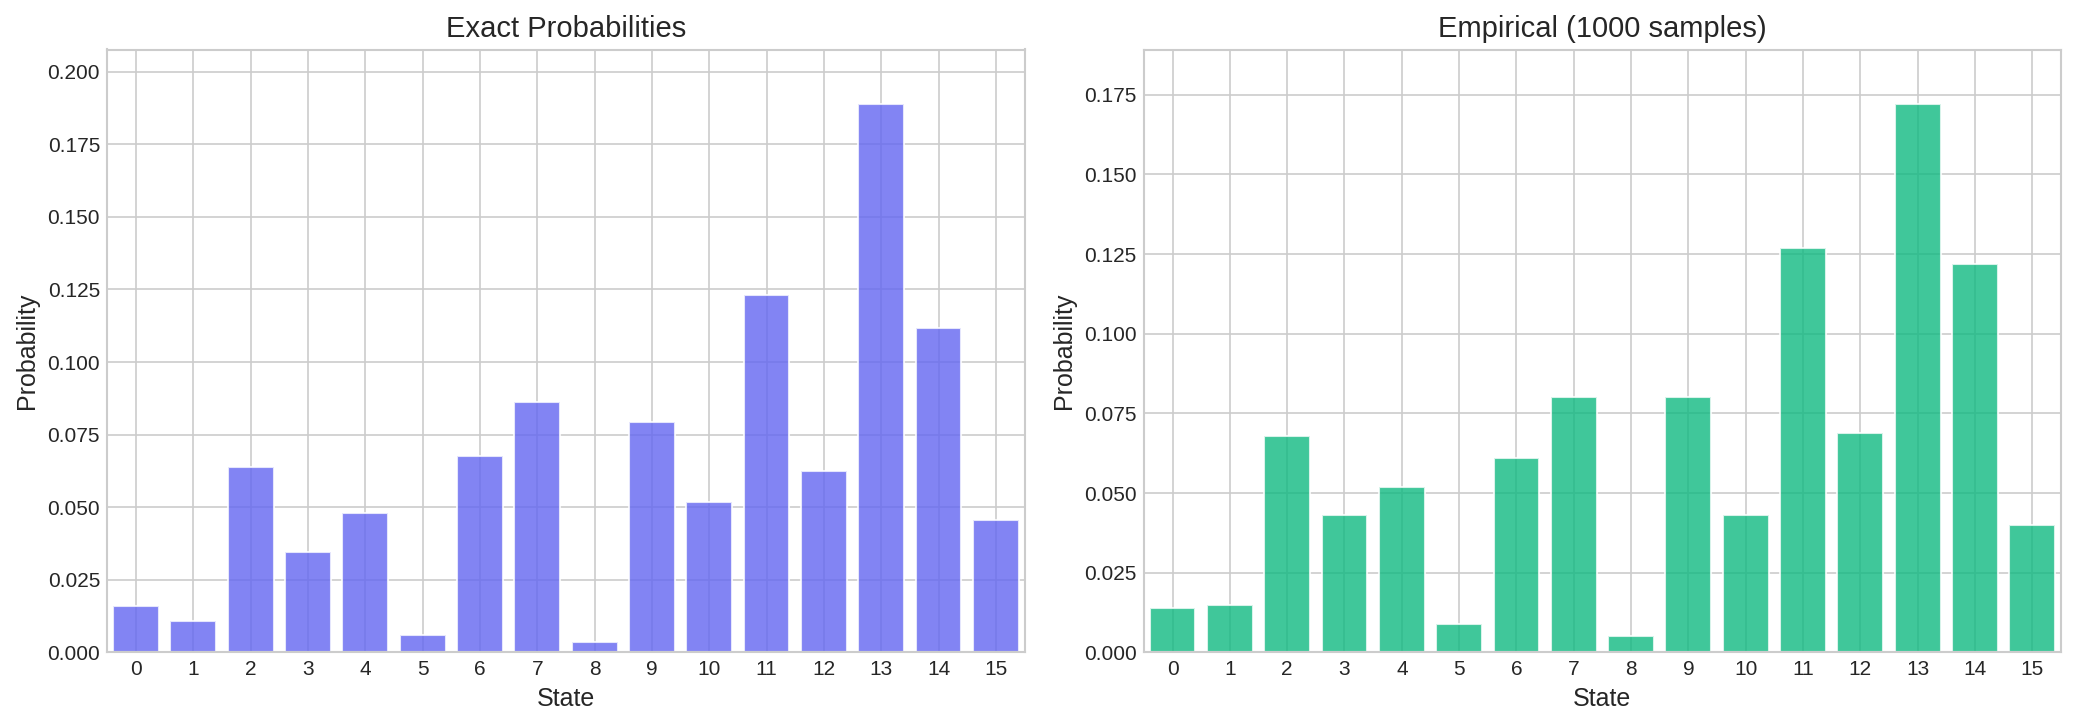

In [20]:
# Sample from the QCBM
qcbm = create_entangled_qcbm(n_qubits=4, n_layers=3)
params = qcbm.get_initial_params(seed=42)

# Generate samples
samples = qcbm.sample(params, n_samples=1000)

print(f" Generated {len(samples)} samples")
print(f"   Sample values: {samples[:20]}...")

# Compare sampling histogram with exact probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exact probabilities
exact_probs = qcbm.get_probabilities(params)
plot_distribution(exact_probs, title='Exact Probabilities', ax=axes[0])

# Empirical from sampling
sample_counts = np.bincount(samples, minlength=16) / len(samples)
plot_distribution(sample_counts, title='Empirical (1000 samples)', ax=axes[1], color='#10B981')

plt.tight_layout()
save_figure(fig, 'sampling_comparison', experiment='exp02')
plt.show()

## 6. Separable vs Entangled: A Preview

In [21]:
# Create both types of QCBM
separable = create_separable_qcbm(n_qubits=4, n_layers=3)
entangled = create_entangled_qcbm(n_qubits=4, n_layers=3)

print(" Comparison: Separable vs Entangled QCBM")
print("=" * 50)
print(f"\n{'Property':<25} {'Separable':<15} {'Entangled':<15}")
print("-" * 55)
print(f"{'Topology':<25} {'None':<15} {'Full':<15}")
print(f"{'Parameters':<25} {separable.n_params:<15} {entangled.n_params:<15}")
print(f"{'CNOT gates':<25} {0:<15} {len(entangled.ansatz.entanglement_pairs) * entangled.n_layers:<15}")
print(f"{'Can represent correlations':<25} {'No':<15} {'Yes':<15}")

 Comparison: Separable vs Entangled QCBM

Property                  Separable       Entangled      
-------------------------------------------------------
Topology                  None            Full           
Parameters                24              24             
CNOT gates                0               18             
Can represent correlations No              Yes            


##  Summary

### Key Concepts:

1. **QCBM uses Born Rule**: Probabilities come directly from $|\langle x|\psi\rangle|^2$

2. **Entanglement Topologies**:
   - `none`: No CNOT gates → separable states (classical baseline)
   - `linear`: Chain connectivity → minimal entanglement
   - `circular`: Ring connectivity → slightly more entanglement
   - `full`: All-to-all → maximum expressibility

3. **Trade-off**: More entanglement = more expressible but harder to train on NISQ devices

### Next Experiment:
→ **Notebook 03:** Train QCBM on Mario dataset and compare Separable vs Entangled

In [22]:
from src.utils.figure_saver import save_current_figure